# Insurance Risk Framework v3
## Clustering -> ML -> Monte Carlo -> Pricing Decision

**Dataset:** freMTPL2 - French Motor Third-Party Liability (OpenML)

| Stage | Question |
|-------|----------|
| 1. Clustering | Who are your customers? |
| 2. ML | What will they do? |
| 3. Monte Carlo | What does it mean for the portfolio? |
| 4. Pricing | How do we price competitively but protected? |

> *Individual prediction = hedging a single position.*  
> *Monte Carlo = stress testing the whole portfolio.*

---
**Changes vs v2:**
- Fix: GLM is now the pricing base; ML provides a ratio adjustment on top
- Fix: ML severity predictions capped at 99th percentile to prevent outlier inflation
- Fix: Blending ratio clipped to [0.5, 2.0] so ML cannot move GLM price by more than 2x
- Kept: all v2 fixes (leakage, threshold tuning, CV, SHAP, MC market shock)


In [1]:
# !pip install scikit-learn numpy pandas matplotlib seaborn shap

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import PoissonRegressor, GammaRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import roc_auc_score

sns.set_theme(style='whitegrid', palette='muted')
PALETTE = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
SEED    = 42

print('Libraries loaded ✓')

Libraries loaded ✓


---
## Stage 0 - Data Loading & Preprocessing

In [3]:
print('Loading freMTPL2 from OpenML (first run ~30s)...')

freq = fetch_openml(data_id=41214, as_frame=True, parser='auto').frame
sev  = fetch_openml(data_id=41215, as_frame=True, parser='auto').frame

print(f'  freq : {freq.shape[0]:,} rows  |  sev : {sev.shape[0]:,} rows')
freq.head()

Loading freMTPL2 from OpenML (first run ~30s)...
  freq : 678,013 rows  |  sev : 26,639 rows


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,'Regular',1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,'Regular',1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,'Diesel',54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,'Diesel',76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,'Diesel',76,R72


In [4]:
sev_agg = (
    sev.groupby('IDpol')['ClaimAmount']
    .sum().reset_index()
    .rename(columns={'ClaimAmount': 'TotalClaimAmount'})
)

df = freq.merge(sev_agg, on='IDpol', how='left')
df['TotalClaimAmount'] = df['TotalClaimAmount'].fillna(0.0)
df['HasClaim']         = (df['ClaimNb'] > 0).astype(int)

for col in ['Area', 'VehBrand', 'VehGas', 'Region']:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

for col in ['ClaimNb', 'Exposure', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna().reset_index(drop=True)
df['Exposure'] = df['Exposure'].clip(lower=0.01)

print(f'Dataset : {len(df):,} policies')
print(f'Claim rate   : {df["HasClaim"].mean():.2%}')
print(f'Avg exposure : {df["Exposure"].mean():.3f} years')
df.describe().round(2)

Dataset : 678,013 policies
Claim rate   : 5.02%
Avg exposure : 0.529 years


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,TotalClaimAmount,HasClaim
count,678013.00,678013.00,678013.00,678013.00,678013.00,678013.00,678013.00,678013.00,678013.00,678013.00,678013.00,678013.00,678013.00,678013.00
mean,2621856.92,0.05,0.53,2.29,6.45,7.04,45.50,59.76,4.05,0.51,1792.42,10.29,88.36,0.05
std,1641782.75,0.24,0.36,1.38,2.05,5.67,14.14,15.64,3.07,0.50,3958.65,6.87,5822.45,0.22
min,1.00,0.00,0.01,0.00,4.00,0.00,18.00,50.00,0.00,0.00,1.00,0.00,0.00,0.00
25%,1157951.00,0.00,0.18,1.00,5.00,2.00,34.00,50.00,1.00,0.00,92.00,4.00,0.00,0.00
50%,2272152.00,0.00,0.49,2.00,6.00,6.00,44.00,50.00,3.00,1.00,393.00,11.00,0.00,0.00
75%,4046274.00,0.00,0.99,3.00,7.00,11.00,55.00,64.00,6.00,1.00,1658.00,17.00,0.00,0.00
max,6114330.00,16.00,2.01,5.00,15.00,100.00,100.00,230.00,10.00,1.00,27000.00,21.00,4075400.56,1.00


---
## Train / Validation / Test Split

Split **before any fitting** to prevent leakage.

| Split | Size | Purpose |
|-------|------|---------|
| Train | 64% | Fit all models + KMeans |
| Validation | 16% | Threshold tuning |
| Test | 20% | Final AUC evaluation only |

In [5]:
ML_FEATURES = ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus',
               'Density', 'Area', 'VehBrand', 'VehGas', 'Region']
# RiskSegment added after clustering below

df_train, df_test = train_test_split(df, test_size=0.20, random_state=SEED, stratify=df['HasClaim'])
df_train, df_val  = train_test_split(df_train, test_size=0.20, random_state=SEED, stratify=df_train['HasClaim'])

print(f'Train : {len(df_train):,}  |  Val : {len(df_val):,}  |  Test : {len(df_test):,}')
print(f'Claim rate - train {df_train["HasClaim"].mean():.2%} | val {df_val["HasClaim"].mean():.2%} | test {df_test["HasClaim"].mean():.2%}')

Train : 433,928  |  Val : 108,482  |  Test : 135,603
Claim rate - train 5.02% | val 5.02% | test 5.02%


---
## Stage 1 - Clustering: Who are your customers?

**FIX v1:** KMeans is now fit on train only, then applied to val/test via `.predict()`.  
Previously fitting on the full dataset caused val/test information to leak into `RiskSegment`.

In [6]:
CLUSTER_FEATURES = ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density', 'Area']

# FIX: fit scaler + KMeans on train only
cl_scaler = StandardScaler()
kmeans    = KMeans(n_clusters=4, random_state=SEED, n_init=10)

X_cl_train = cl_scaler.fit_transform(df_train[CLUSTER_FEATURES])
kmeans.fit(X_cl_train)

df_train = df_train.copy()
df_val   = df_val.copy()
df_test  = df_test.copy()

df_train['RiskSegment'] = kmeans.predict(X_cl_train)
df_val['RiskSegment']   = kmeans.predict(cl_scaler.transform(df_val[CLUSTER_FEATURES]))
df_test['RiskSegment']  = kmeans.predict(cl_scaler.transform(df_test[CLUSTER_FEATURES]))

ALL_FEATURES = ML_FEATURES + ['RiskSegment']

segment_profile = df_train.groupby('RiskSegment').agg(
    n_policies       = ('IDpol',           'count'),
    claim_rate       = ('HasClaim',         'mean'),
    avg_bonus_malus  = ('BonusMalus',       'mean'),
    avg_driver_age   = ('DrivAge',          'mean'),
    avg_claim_amount = ('TotalClaimAmount', 'mean'),
).round(3)

segment_profile

,n_policies,claim_rate,avg_bonus_malus,avg_driver_age,avg_claim_amount
RiskSegment,,,,,
0,10089,0.061,63.272,46.762,78.150
1,174566,0.051,52.750,49.836,72.888
2,93300,0.059,84.582,31.454,187.437
3,155973,0.044,52.595,48.951,60.437


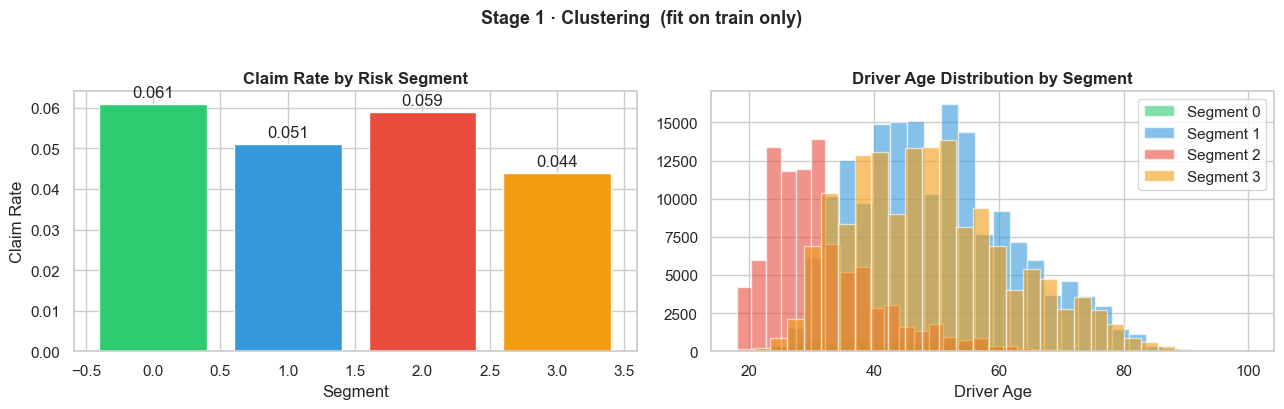

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bars = axes[0].bar(segment_profile.index, segment_profile['claim_rate'],
                   color=PALETTE, edgecolor='white')
axes[0].bar_label(bars, fmt='%.3f', padding=3)
axes[0].set_title('Claim Rate by Risk Segment', fontweight='bold')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Claim Rate')

for seg, color in zip(sorted(df_train['RiskSegment'].unique()), PALETTE):
    axes[1].hist(df_train.loc[df_train['RiskSegment'] == seg, 'DrivAge'],
                 bins=30, alpha=0.6, color=color, label=f'Segment {seg}')
axes[1].set_title('Driver Age Distribution by Segment', fontweight='bold')
axes[1].set_xlabel('Driver Age')
axes[1].legend()

plt.suptitle('Stage 1 · Clustering  (fit on train only)', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Stage 2a - GLM Baseline

**FIX v1:** Features are now scaled before passing to GLM.  
Poisson/Gamma regularisation is sensitive to feature scale - without scaling, the solver fails to differentiate between segments and converges to the same mean for every group.

In [8]:
# FIX: scale for GLM
glm_scaler = StandardScaler()
X_glm_tr   = glm_scaler.fit_transform(df_train[ALL_FEATURES])
X_glm_val  = glm_scaler.transform(df_val[ALL_FEATURES])
X_glm_te   = glm_scaler.transform(df_test[ALL_FEATURES])

# Frequency - Poisson, exposure-weighted
freq_model = PoissonRegressor(max_iter=5000, alpha=0.1)
freq_model.fit(X_glm_tr, df_train['ClaimNb'], sample_weight=df_train['Exposure'])
print(f'Frequency model: converged in {freq_model.n_iter_} iterations')

# Severity - Gamma, claims only
claims_mask_tr = df_train['TotalClaimAmount'] > 0
sev_model = GammaRegressor(max_iter=5000, alpha=0.1)
sev_model.fit(X_glm_tr[claims_mask_tr], df_train.loc[claims_mask_tr, 'TotalClaimAmount'])
print(f'Severity model:  converged in {sev_model.n_iter_} iterations')

for df_split, X_glm in [(df_train, X_glm_tr), (df_val, X_glm_val), (df_test, X_glm_te)]:
    df_split['GLM_FreqPred']    = freq_model.predict(X_glm)
    df_split['GLM_SevPred']     = sev_model.predict(X_glm).clip(min=0)
    df_split['GLM_PurePremium'] = df_split['GLM_FreqPred'] * df_split['GLM_SevPred']

print('\nGLM pure premium by segment (test):')
df_test.groupby('RiskSegment')['GLM_PurePremium'].mean().round(2)

Frequency model: converged in 5 iterations
Severity model:  converged in 10 iterations

GLM pure premium by segment (test):


RiskSegment
0    180.20
1    134.21
2    245.31
3    124.03
Name: GLM_PurePremium, dtype: float64

---
## Stage 2b - ML Layer

**FIX v1:**
- `sample_weight = Exposure × class_weight` - longer-exposure policies carry more weight; minority class (claimants, ~5%) upweighted
- Threshold tuning on **validation set** - test set held out until final evaluation

In [9]:
X_tr  = df_train[ALL_FEATURES]
X_val = df_val[ALL_FEATURES]
X_te  = df_test[ALL_FEATURES]

y_tr  = df_train['HasClaim']
y_val = df_val['HasClaim']
y_te  = df_test['HasClaim']

# FIX: combined exposure + class-imbalance weight
claim_rate = y_tr.mean()
sw_train   = df_train['Exposure'] * np.where(
    y_tr == 1, 1 / claim_rate, 1 / (1 - claim_rate)
)

clf = GradientBoostingClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=SEED
)
clf.fit(X_tr, y_tr, sample_weight=sw_train)

prob_val = clf.predict_proba(X_val)[:, 1]
prob_te  = clf.predict_proba(X_te)[:, 1]

auc_val  = roc_auc_score(y_val, prob_val)
auc_test = roc_auc_score(y_te,  prob_te)

print(f'AUC - validation      : {auc_val:.4f}')
print(f'AUC - test (held-out) : {auc_test:.4f}')

df_train['ML_ClaimProb'] = clf.predict_proba(X_tr)[:, 1]
df_val['ML_ClaimProb']   = prob_val
df_test['ML_ClaimProb']  = prob_te

AUC - validation      : 0.6563
AUC - test (held-out) : 0.6511


### Threshold Tuning - on Validation Set Only

**FIX v1:** Threshold previously found on test set → contaminated final evaluation.  
Now: optimal threshold found on **val**, cost reduction reported on **test**.

In [10]:
FN_WEIGHT, FP_WEIGHT = 5, 1

cost_rows = []
for t in np.arange(0.05, 0.65, 0.01):
    pred = (prob_val >= t).astype(int)        # ← val set only
    fn   = ((pred == 0) & (y_val == 1)).sum()
    fp   = ((pred == 1) & (y_val == 0)).sum()
    cost_rows.append({'threshold': t, 'cost': fn*FN_WEIGHT + fp*FP_WEIGHT,
                      'fn': fn, 'fp': fp})

cost_df        = pd.DataFrame(cost_rows)
best           = cost_df.loc[cost_df['cost'].idxmin()]
BEST_THRESHOLD = float(best['threshold'])

for df_split in [df_train, df_val, df_test]:
    df_split['ML_HighRisk'] = (df_split['ML_ClaimProb'] >= BEST_THRESHOLD).astype(int)

# Honest cost comparison on test
pred_te      = (prob_te >= BEST_THRESHOLD).astype(int)
pred_default = (prob_te >= 0.50).astype(int)

cost_opt = (((pred_te == 0) & (y_te == 1)).sum() * FN_WEIGHT +
            ((pred_te == 1) & (y_te == 0)).sum() * FP_WEIGHT)
cost_def = (((pred_default == 0) & (y_te == 1)).sum() * FN_WEIGHT +
            ((pred_default == 1) & (y_te == 0)).sum() * FP_WEIGHT)

print(f'Optimal threshold (found on val) : {BEST_THRESHOLD:.2f}')
print(f'Test cost - default 0.50         : {cost_def:,.0f}')
print(f'Test cost - optimal {BEST_THRESHOLD:.2f}         : {cost_opt:,.0f}')
print(f'Cost reduction on test           : {(1 - cost_opt/cost_def):.1%}')

Optimal threshold (found on val) : 0.64
Test cost - default 0.50         : 78,050
Test cost - optimal 0.64         : 40,152
Cost reduction on test           : 48.6%


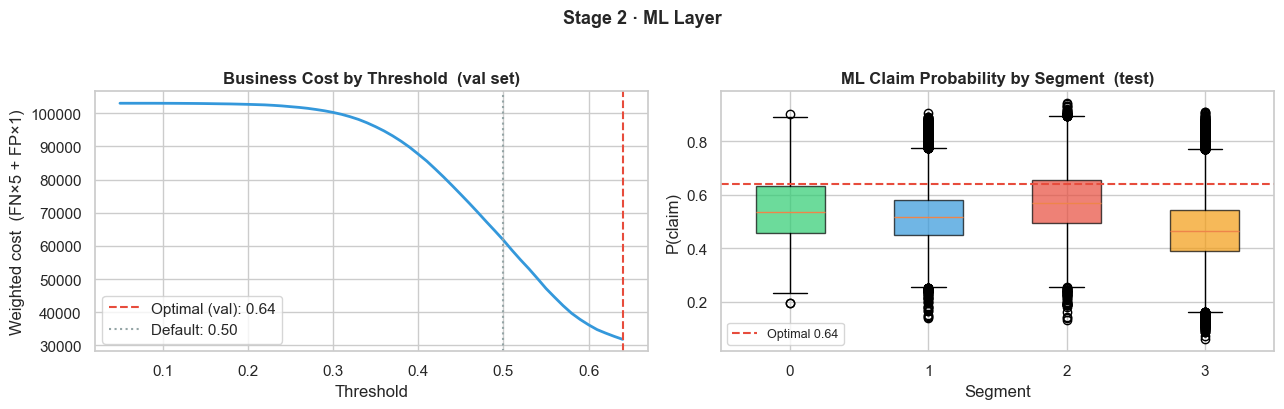

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(cost_df['threshold'], cost_df['cost'], color='#3498db', linewidth=2)
axes[0].axvline(BEST_THRESHOLD, color='#e74c3c', linestyle='--',
                label=f'Optimal (val): {BEST_THRESHOLD:.2f}')
axes[0].axvline(0.50, color='#95a5a6', linestyle=':', label='Default: 0.50')
axes[0].set_title('Business Cost by Threshold  (val set)', fontweight='bold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Weighted cost  (FN×5 + FP×1)')
axes[0].legend()

data_bp = [df_test.loc[df_test['RiskSegment'] == s, 'ML_ClaimProb'].values
           for s in sorted(df_test['RiskSegment'].unique())]
bp = axes[1].boxplot(data_bp, patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].axhline(BEST_THRESHOLD, color='#e74c3c', linestyle='--',
                label=f'Optimal {BEST_THRESHOLD:.2f}')
axes[1].set_title('ML Claim Probability by Segment  (test)', fontweight='bold')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('P(claim)')
axes[1].set_xticklabels(sorted(df_test['RiskSegment'].unique()))
axes[1].legend(fontsize=9)

plt.suptitle('Stage 2 · ML Layer', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

### Cross-Validation - AUC Stability

**NEW v2:** Single split results are sensitive to the random seed.  
5-fold stratified CV confirms the AUC is stable across folds.

In [12]:
df_tv = pd.concat([df_train, df_val]).reset_index(drop=True)
X_tv  = df_tv[ALL_FEATURES]
y_tv  = df_tv['HasClaim']

cr_tv = y_tv.mean()
sw_tv = df_tv['Exposure'] * np.where(y_tv == 1, 1/cr_tv, 1/(1-cr_tv))

cv_clf = GradientBoostingClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=SEED
)

skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_auc = []

for fold, (idx_tr, idx_val) in enumerate(skf.split(X_tv, y_tv)):
    cv_clf.fit(X_tv.iloc[idx_tr], y_tv.iloc[idx_tr], sample_weight=sw_tv.iloc[idx_tr])
    auc_fold = roc_auc_score(y_tv.iloc[idx_val], cv_clf.predict_proba(X_tv.iloc[idx_val])[:, 1])
    cv_auc.append(auc_fold)
    print(f'  Fold {fold+1}: AUC = {auc_fold:.4f}')

print(f'\n  CV AUC  mean ± std  : {np.mean(cv_auc):.4f} ± {np.std(cv_auc):.4f}')
print(f'  Test AUC (held-out) : {auc_test:.4f}')

  Fold 1: AUC = 0.6541
  Fold 2: AUC = 0.6514
  Fold 3: AUC = 0.6500
  Fold 4: AUC = 0.6538
  Fold 5: AUC = 0.6513

  CV AUC  mean ± std  : 0.6521 ± 0.0016
  Test AUC (held-out) : 0.6511


### Severity Model

In [13]:
claims_mask_tr = df_train['TotalClaimAmount'] > 0

sev_reg = GradientBoostingRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=SEED
)
sev_reg.fit(
    X_tr[claims_mask_tr],
    df_train.loc[claims_mask_tr, 'TotalClaimAmount'],
    sample_weight=df_train.loc[claims_mask_tr, 'Exposure']
)

# Cap severity predictions at 99th percentile to prevent outlier inflation
sev_cap = np.percentile(df_train.loc[claims_mask_tr, 'TotalClaimAmount'], 99)
print(f'Severity cap (99th pct of train claims) : ${sev_cap:,.0f}')

for df_split, X_split in [(df_train, X_tr), (df_val, X_val), (df_test, X_te)]:
    df_split['ML_SevPred']     = sev_reg.predict(X_split).clip(0, sev_cap)
    df_split['ML_PurePremium'] = df_split['ML_ClaimProb'] * df_split['ML_SevPred']

print('GLM vs ML pure premium by segment (test):')
df_test.groupby('RiskSegment')[['GLM_PurePremium', 'ML_PurePremium']].mean().round(2)


Severity cap (99th pct of train claims) : $18,822
GLM vs ML pure premium by segment (test):


,GLM_PurePremium,ML_PurePremium
RiskSegment,,
0,180.20,1251.13
1,134.21,957.29
2,245.31,1281.28
3,124.03,822.78


---
## Stage 2c - SHAP Interpretability

**NEW v2:** In insurance, models influencing underwriting decisions must be explainable - both for internal governance and regulatory review.  
SHAP shows which features drive each individual prediction, not just average importance.

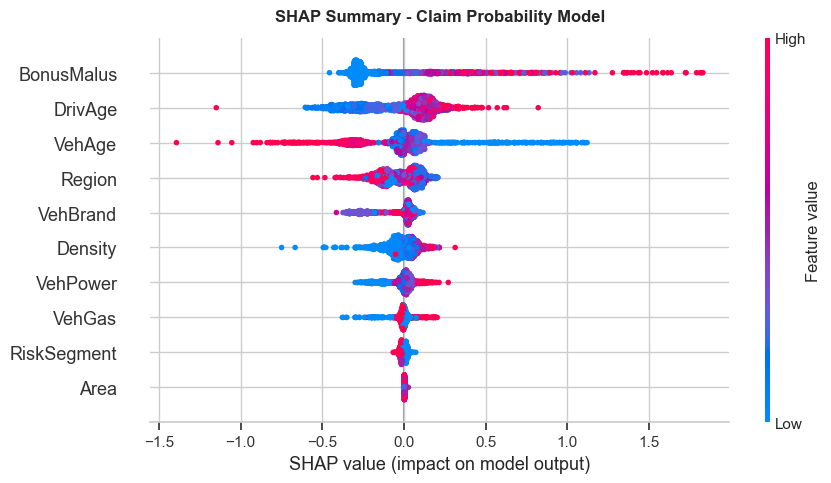

In [14]:
X_shap      = X_te.sample(2000, random_state=SEED)
explainer   = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_shap, feature_names=ALL_FEATURES, show=False, plot_size=None)
plt.title('SHAP Summary - Claim Probability Model', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

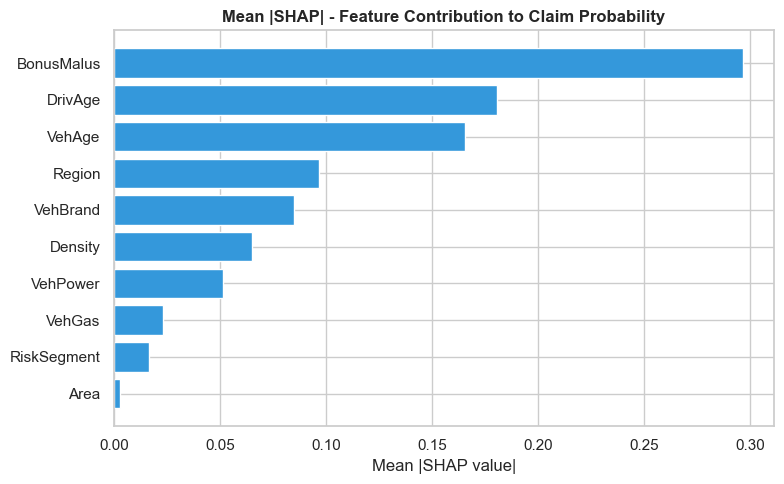

Top 3 drivers:
BonusMalus    0.2966
DrivAge       0.1805
VehAge        0.1657


In [15]:
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0), index=ALL_FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(mean_shap.index, mean_shap.values, color='#3498db', edgecolor='white')
ax.set_title('Mean |SHAP| - Feature Contribution to Claim Probability', fontweight='bold')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()

print('Top 3 drivers:')
print(mean_shap.tail(3).iloc[::-1].round(4).to_string())

---
## Stage 3 - Monte Carlo: What does it mean for the portfolio?

**FIX v2:** Added systematic market shock - a shared factor applied across all policies per simulation.  
Captures correlated events (severe weather, economic downturns) that independent Bernoulli draws miss.  
This widens the tail and produces a more conservative, realistic reserve estimate.

In [16]:
N_SIMS     = 1_000
SHOCK_STD  = 0.08   # ~8% portfolio-level volatility from correlated events

probs   = df_test['ML_ClaimProb'].values
amounts = df_test['ML_SevPred'].values

rng          = np.random.default_rng(SEED)
total_losses = np.empty(N_SIMS)

for i in range(N_SIMS):
    # FIX: systematic shock - same event hits all policies in a scenario
    market_shock     = np.exp(rng.normal(0.0, SHOCK_STD))
    occurred         = rng.binomial(1, np.clip(probs * market_shock, 0, 1))
    idio_noise       = rng.lognormal(0.0, 0.25, len(amounts))
    total_losses[i]  = (occurred * amounts * idio_noise).sum()

avg_loss = total_losses.mean()
pct95    = np.percentile(total_losses, 95)
pct99    = np.percentile(total_losses, 99)

print(f'Expected portfolio loss          : ${avg_loss:>15,.0f}')
print(f'95th percentile (reserve req.)   : ${pct95:>15,.0f}')
print(f'99th percentile (tail risk)      : ${pct99:>15,.0f}')
print(f'Capital buffer needed            : ${pct95 - avg_loss:>15,.0f}')

Expected portfolio loss          : $    138,276,057
95th percentile (reserve req.)   : $    156,142,939
99th percentile (tail risk)      : $    163,973,197
Capital buffer needed            : $     17,866,882


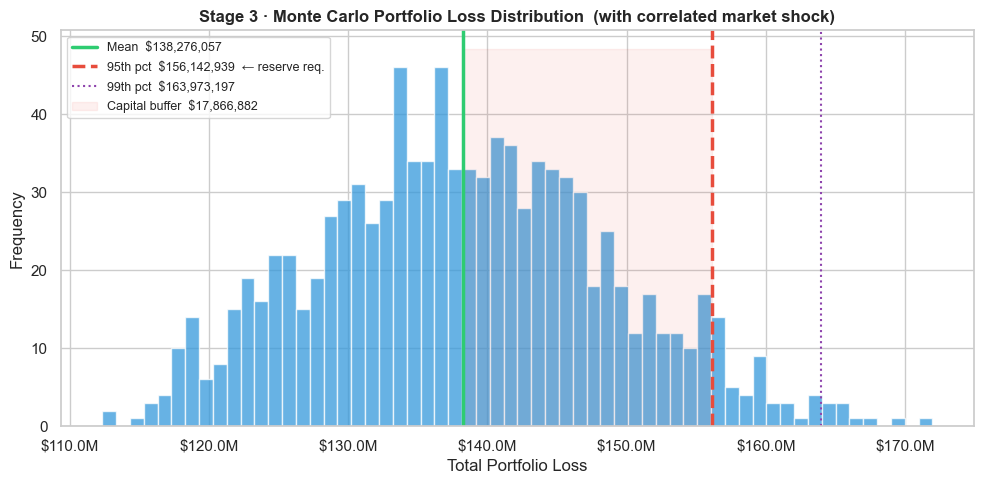

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(total_losses, bins=60, color='#3498db', alpha=0.75, edgecolor='white')
ax.axvline(avg_loss, color='#2ecc71', linewidth=2.5,
           label=f'Mean  ${avg_loss:,.0f}')
ax.axvline(pct95, color='#e74c3c', linewidth=2.5, linestyle='--',
           label=f'95th pct  ${pct95:,.0f}  ← reserve req.')
ax.axvline(pct99, color='#8e44ad', linewidth=1.5, linestyle=':',
           label=f'99th pct  ${pct99:,.0f}')
ax.fill_betweenx([0, ax.get_ylim()[1] or 1], avg_loss, pct95,
                 alpha=0.08, color='#e74c3c',
                 label=f'Capital buffer  ${pct95-avg_loss:,.0f}')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_title('Stage 3 · Monte Carlo Portfolio Loss Distribution  (with correlated market shock)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Total Portfolio Loss')
ax.set_ylabel('Frequency')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Stage 4 - Pricing Decision

In [18]:
# GLM base + ML ratio adjustment
# ML_ratio: how much ML deviates from GLM per policy
# Clipped to [0.5, 2.0] so ML cannot move price more than 2x either direction
ML_CLIP_LOW, ML_CLIP_HIGH = 0.5, 2.0

df_test['ML_ratio']     = (df_test['ML_PurePremium'] / df_test['GLM_PurePremium']).clip(ML_CLIP_LOW, ML_CLIP_HIGH)
df_test['BlendPremium'] = df_test['GLM_PurePremium'] * df_test['ML_ratio']
loading_factor          = pct95 / avg_loss
df_test['FinalPremium'] = df_test['BlendPremium'] * loading_factor

pricing_comparison = df_test.groupby('RiskSegment').agg(
    n_policies        = ('IDpol',           'count'),
    actual_claim_rate = ('HasClaim',         'mean'),
    glm_premium       = ('GLM_PurePremium',  'mean'),
    ml_premium        = ('ML_PurePremium',   'mean'),
    blend_premium     = ('BlendPremium',     'mean'),
    final_premium     = ('FinalPremium',     'mean'),
).round(2)

print(f'ML ratio clip range     : [{ML_CLIP_LOW}, {ML_CLIP_HIGH}]')
print(f'Monte Carlo loading factor : {loading_factor:.3f}x')
print()
pricing_comparison


ML ratio clip range     : [0.5, 2.0]
Monte Carlo loading factor : 1.129x



,n_policies,actual_claim_rate,glm_premium,ml_premium,blend_premium,final_premium
RiskSegment,,,,,,
0,3216,0.06,180.20,1251.13,234.56,264.87
1,54472,0.05,134.21,957.29,265.66,299.99
2,29113,0.06,245.31,1281.28,473.01,534.12
3,48802,0.04,124.03,822.78,245.34,277.04


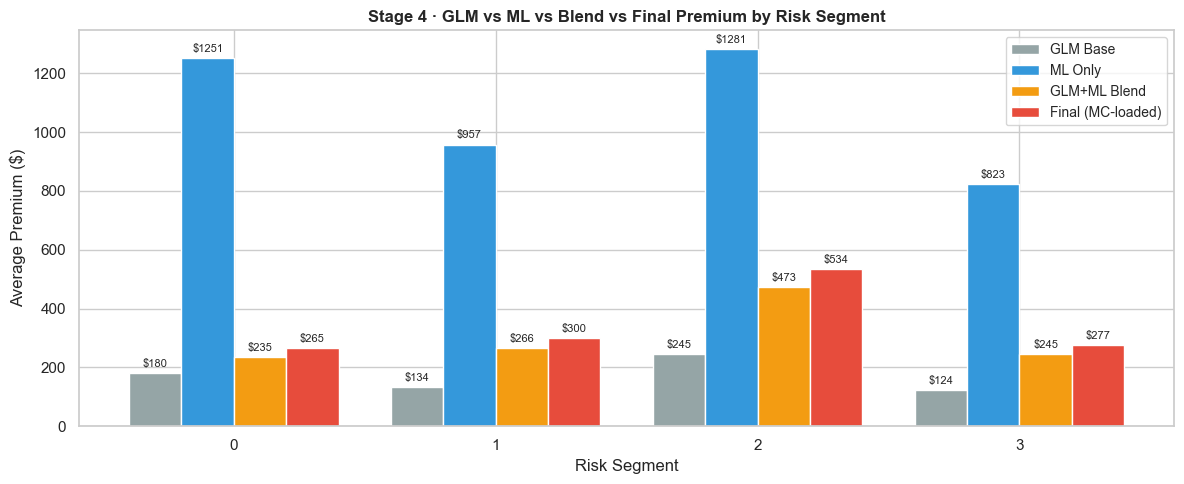

In [19]:
seg_pricing = df_test.groupby('RiskSegment')[['GLM_PurePremium', 'ML_PurePremium', 'BlendPremium', 'FinalPremium']].mean()

x      = np.arange(len(seg_pricing))
width  = 0.2
labels = ['GLM Base', 'ML Only', 'GLM+ML Blend', 'Final (MC-loaded)']
colors = ['#95a5a6', '#3498db', '#f39c12', '#e74c3c']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (col, label, color) in enumerate(zip(seg_pricing.columns, labels, colors)):
    bars = ax.bar(x + i*width, seg_pricing[col], width,
                  label=label, color=color, edgecolor='white')
    ax.bar_label(bars, fmt='${:.0f}', padding=3, fontsize=8)

ax.set_title('Stage 4 · GLM vs ML vs Blend vs Final Premium by Risk Segment', fontweight='bold', fontsize=12)
ax.set_xlabel('Risk Segment')
ax.set_ylabel('Average Premium ($)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(seg_pricing.index)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


---
## Summary

In [20]:
print('=' * 60)
print('FULL FRAMEWORK SUMMARY  (v3)')
print('=' * 60)
print(f'  Train / Val / Test       : {len(df_train):,} / {len(df_val):,} / {len(df_test):,}')
print(f'  Claim rate               : {df["HasClaim"].mean():.2%}')
print()
print(f'  CV AUC  mean ± std       : {np.mean(cv_auc):.4f} ± {np.std(cv_auc):.4f}')
print(f'  Test AUC (held-out)      : {auc_test:.4f}')
print(f'  Optimal threshold        : {BEST_THRESHOLD:.2f}  (tuned on val, applied to test)')
print()
print(f'  MC expected loss         : ${avg_loss:,.0f}')
print(f'  MC 95th pct reserve      : ${pct95:,.0f}')
print(f'  Capital buffer           : ${pct95 - avg_loss:,.0f}')
print(f'  Loading factor           : {loading_factor:.3f}x')
print()
print('  Pricing structure (v3):')
print('    GLM = base premium (regulator-friendly, interpretable)')
print('    ML  = ratio adjustment on GLM, clipped to [0.5, 2.0]')
print('    Final = GLM x ML_ratio x MC_loading')
print()
print('  Changes vs v2:')
print('    Fixed: GLM base + ML adjustment (not ML-only)')
print('    Fixed: ML severity capped at 99th percentile')
print('    Fixed: ML ratio clipped to prevent extreme pricing')
print('    Kept:  all v2 leakage, threshold, CV, SHAP, MC fixes')
print()
print('  Individual prediction  = hedging a single position')
print('  Monte Carlo            = stress testing the whole portfolio')
print('  The domain changes. The decision problem does not.')
print('=' * 60)


FULL FRAMEWORK SUMMARY  (v3)
  Train / Val / Test       : 433,928 / 108,482 / 135,603
  Claim rate               : 5.02%

  CV AUC  mean ± std       : 0.6521 ± 0.0016
  Test AUC (held-out)      : 0.6511
  Optimal threshold        : 0.64  (tuned on val, applied to test)

  MC expected loss         : $138,276,057
  MC 95th pct reserve      : $156,142,939
  Capital buffer           : $17,866,882
  Loading factor           : 1.129x

  Pricing structure (v3):
    GLM = base premium (regulator-friendly, interpretable)
    ML  = ratio adjustment on GLM, clipped to [0.5, 2.0]
    Final = GLM x ML_ratio x MC_loading

  Changes vs v2:
    Fixed: GLM base + ML adjustment (not ML-only)
    Fixed: ML severity capped at 99th percentile
    Fixed: ML ratio clipped to prevent extreme pricing
    Kept:  all v2 leakage, threshold, CV, SHAP, MC fixes

  Individual prediction  = hedging a single position
  Monte Carlo            = stress testing the whole portfolio
  The domain changes. The decision probl